# Physical Experiment Notch: Single Beam Calibration

In this notebook, we compare our theoretical predictions with our actual measurements, by loading the myDAQ logs. First, we will try to match a single beam response to our model.

Let us import our tools first:

In [4]:
# Import modules:
from beam_manager import open_beam_library, sublibrary
from bridge_manager_v2 import Bridge
from myDAQ_manager import logs_to_U

import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt

Next, we load our real beam library, consisting of actual components from our toolbox:

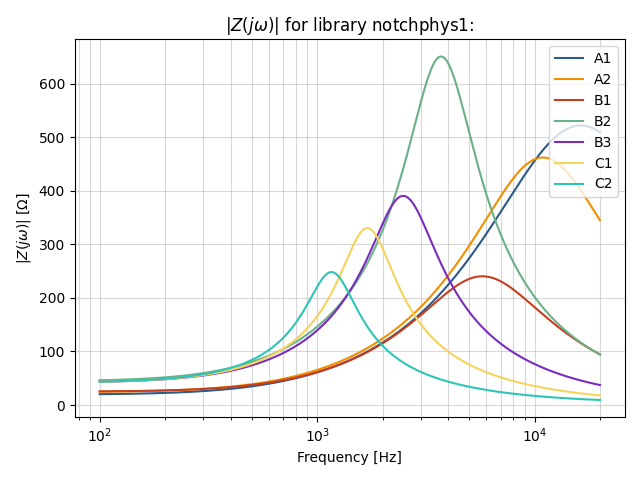

In [5]:
library_name = 'notchphys1'
library = open_beam_library(library_name + '.json')

fig, ax = plt.subplots()
colors = ['#2E5A88', '#F18F01', '#C73E1D', '#6AB187', '#7B2CBF', '#F4D35E', '#2EC4B6']
f_logrange = (2, np.log10(2e4)) # max frequency sweep between 100 and 20 000 Hz (audio range)
f_start, f_stop = f_logrange
f_arr = np.logspace(f_start, f_stop, 2000)

for beam, color in zip(list(library.values()), colors):
    beam.impedance_plot(ax, f_arr, color)

ax.grid(True, which="both", ls="-", alpha=0.5)
ax.set_ylabel(r'$|Z(j\omega)|$ [$\Omega$]')
ax.set_xlabel('Frequency [Hz]')
ax.legend(loc='upper right')

plt.title(fr'$|Z(j\omega)|$ for library {library_name}:')
plt.tight_layout()
plt.show()

We must construct the single beam bridge, to view its theoretical frequency response:

Resonance frequencies: Theory: 16277.055, Measurements: 15378.33


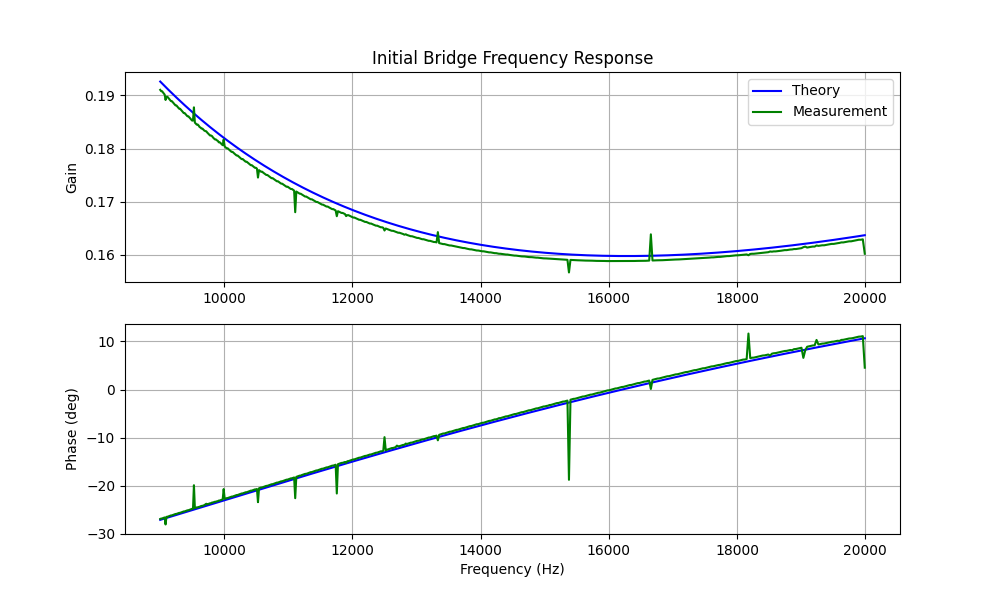

In [6]:
selection = ['A1']
lib = sublibrary(selection, library)

R_ref = 99.2 # Ohm

f_logrange = (2, np.log10(2e4)) # max frequency sweep between 100 and 20 000 Hz (audio range)

topology = [(0, 1)]
struc = Bridge()
struc.construct(lib, topology)


# Measured (initial) beam response:
filename = 'A1-536ohm-9-20kHz-2.1.txt'
f_arr_mes, gain_mes, phase_mes = logs_to_U(filename, Cartesian=False)
_, U_out_mes = logs_to_U(filename, Cartesian=True)

# Theoretical (initial) beam response:
U_initial = struc.initial_response(f_arr_mes, R_ref, plot=False)
gain_theory = np.abs(U_initial)
phase_theory = np.degrees(np.angle(U_initial))

# Plot to compare:
plt.figure(figsize=(10, 6))

# Plot Magnitude
plt.subplot(2, 1, 1)
plt.plot(f_arr_mes, gain_theory, color='b', label='Theory')
plt.plot(f_arr_mes, gain_mes, color='g', label='Measurement')
plt.ylabel('Gain')
plt.grid(True, which="both")
plt.legend()
plt.title('Initial Bridge Frequency Response')

# Plot Phase:
plt.subplot(2, 1, 2)
plt.plot(f_arr_mes, phase_theory, color='b', label='Theory')
plt.plot(f_arr_mes, phase_mes, color='g', label='Measurement')
plt.ylabel('Phase (deg)')
plt.xlabel('Frequency (Hz)')
plt.grid(True, which="both", ls="-")

f_res_theory = f_arr_mes[np.argmin(gain_theory)]
f_res_mes = f_arr_mes[np.argmin(gain_mes)]

print(f'Resonance frequencies: Theory: {f_res_theory}, Measurements: {f_res_mes}')

Let's give the solver a chance at predicting the (initial resistance) value!

R-values found, generating plot...
The correct R values were [536.0], and the solver predicted [539.89931027].


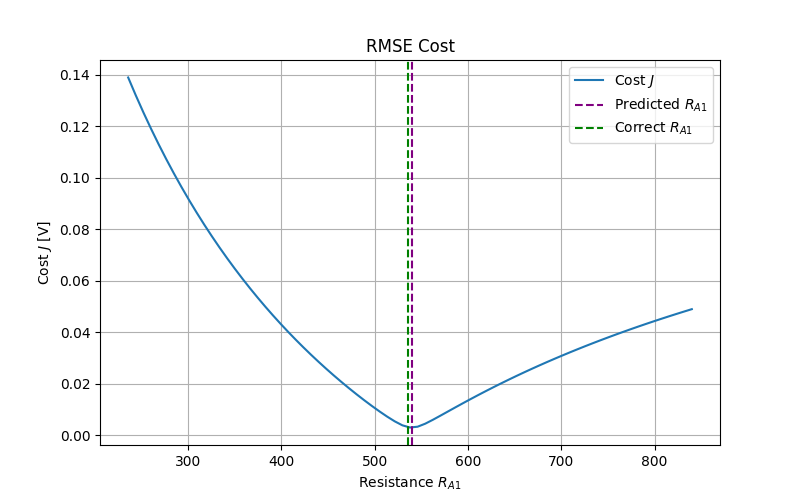

In [7]:
R_def = [5.36e2] # Initial resistance for our build filter!

R_pred = struc.predict_R(R_ref, myDAQ=True, f_arr_mes=f_arr_mes, U_out_mes=U_out_mes, resonance_sweep=False, 
                         error_plot=True, R_var=[0], R_def=R_def, response_comparison_plot=False)


print(f'The correct R values were {R_def}, and the solver predicted {R_pred}.')

## Notities:
- Kalibreer alleen op de dip: dit is waar de informatie ligt en waar `resonance_sweep=True` zal zoeken.
    - Gebruik meerdere weerstandswaarden voor kalibratie, i.p.v. meerdere f-ranges.
- Herkalibreer als een nieuwe constructie is gebouwd! Dat kan automatisch als standaard, op basis van de database R_0 waardes. Herkalibreer enkel op R_contact.

Het is belangrijk de volgende eigenschappen te onthouden:
- Seriegeschakelde weerstanden corrigeren over het hele frequentiedomein
- Parallel geschakelde weerstanden corrigeren het resonantiegebied
- Hoge frequenties worden gedomineerd door de capacitortak
- Lage frequenties worden gedomineerd door de spoeltak

Voor 13-5 (woensdag): toch kalibratiecode maken, op basis van meerdere sweeps. Kalibreer L, C, R_cap en R_contact.

Wat was de methode die leek te werken? Meet L, C en R_coil voor het solderen van de filter. Meet achteraf de dissipatie R_cap en bepaal R_contact. Afwijkingen liggen in de +- 10 Ohm range. De nieuwe kalibratiefunctie is nog niet getest.